In [ ]:
from sklearn.decomposition import TruncatedSVD
import string
import base64
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


def train_and_evaluate(
    x_train,
    x_test,
    y_train,
    y_test,
    labels,
    classifier,
    vectorizer="tfidf",
    use_time_features=True,
    scale_time_features=True,
    dim_reduction=None,    
    model_name=""
):
    
    if vectorizer == "tfidf":
        text_vectorizer = TfidfVectorizer(lowercase=True, token_pattern=r'[^\s|;(){}:\'\"><]+')
    elif vectorizer == "bow":
        text_vectorizer = CountVectorizer(lowercase=True, token_pattern=r'[^\s|;(){}:\'\"><]+')
    else:
        raise ValueError("vectorizer must be 'tfidf' or 'bow'")

    X_text_temp = text_vectorizer.fit_transform(x_train["decoded_payload"])
    n_features = X_text_temp.shape[1]

    if dim_reduction and n_features > 1:
        n_components = min(dim_reduction, n_features - 1)
        text_pipeline = Pipeline([
            ("vectorizer", text_vectorizer),
            ("dim_red", TruncatedSVD(n_components=n_components, random_state=42))
        ])
        print(f"[INFO] Applying TruncatedSVD with {n_components} components (features available: {n_features})")
    else:
        if dim_reduction:
            print(f"[WARNING] Not enough features ({n_features}) for TruncatedSVD. Skipping dimensionality reduction.")
        text_pipeline = text_vectorizer

    
    transformers = [("text", text_pipeline, "decoded_payload")]

    if use_time_features:
        if isinstance(classifier, MultinomialNB):
            time_transformer = "passthrough"
        else:
            time_transformer = StandardScaler() if scale_time_features else "passthrough"
        transformers.append(("time", time_transformer, ["day_of_the_week", "month"]))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    
    model = Pipeline([
        ("preprocessing", preprocessor),
        ("clf", OneVsRestClassifier(classifier))
    ])

   
    model.fit(x_train, y_train)

   
    y_pred_test = model.predict(x_test)
    y_pred_train = model.predict(x_train)

   
    print(f"\n===== {model_name} – TEST =====\n")
    report_test = classification_report(y_test, y_pred_test, target_names=labels,output_dict=True, zero_division=0)
    print(report_test)

    print(f"\n===== {model_name} – TRAIN =====\n")
    report_train = classification_report(y_train, y_pred_train, target_names=labels,output_dict=True, zero_division=0)
    print(report_train)

    return report_test,report_train


In [ ]:
import string
import base64
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


dataSet = pd.read_parquet("../data/ssh_attacks.parquet")

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)




In [ ]:
newDataSet = dataSet.copy()

newDataSet["decoded_payload"] = newDataSet["decoded_payload"].fillna("").astype(str)

newDataSet["first_timestamp"] = pd.to_datetime(newDataSet["first_timestamp"])
newDataSet["day_of_the_week"] = newDataSet["first_timestamp"].dt.dayofweek
newDataSet["month"] = newDataSet["first_timestamp"].dt.month

y = newDataSet['Set_Fingerprint']
binary = MultiLabelBinarizer()
y = binary.fit_transform(y)

newDataSet.drop(columns=['Set_Fingerprint','full_session','session_id'], inplace=True)


X_train, X_test, y_train, y_test = train_test_split(
    newDataSet,
    y,
    train_size=0.7,
    random_state=42,
)


In [ ]:
from itertools import product


def run_all_experiments_best(
    x_train,
    x_test,
    y_train,
    y_test,
    labels,
    metric="macro avg"  
):
    results = []

    vectorizers = ["tfidf", "bow"]
    use_time_opts = [True, False]
    scale_time_opts = [True, False]
    dim_reductions = [None, 100]

    classifiers = {
        "NB": MultinomialNB(),
        "LogReg": LogisticRegression(max_iter=1000, n_jobs=-1)
    }

    
    for (
        vectorizer,
        use_time,
        scale_time,
        dim_red,
        (clf_name, clf)
    ) in product(
        vectorizers,
        use_time_opts,
        scale_time_opts,
        dim_reductions,
        classifiers.items()
    ):

        
        if isinstance(clf, MultinomialNB):
            if dim_red is not None:
                continue
            if scale_time:
                continue
        if not use_time and scale_time:
            continue

        model_name = f"{clf_name} | {vectorizer} | time={use_time} | scale={scale_time} | svd={dim_red}"

        
        report = train_and_evaluate(
            x_train=x_train,
            x_test=x_test,
            y_train=y_train,
            y_test=y_test,
            labels=labels,
            classifier=clf,
            vectorizer=vectorizer,
            use_time_features=use_time,
            scale_time_features=scale_time,
            dim_reduction=dim_red,
            model_name=model_name
        )

        report_test = report[0]
        macro_f1 = report_test[metric]["f1-score"]

        per_class_f1 = {label: report_test[label]["f1-score"] for label in labels}

        results.append({
            "model_name": model_name,
            "classifier": clf_name,
            "vectorizer": vectorizer,
            "use_time": use_time,
            "scale_time": scale_time,
            "svd": dim_red,
            "macro_f1": macro_f1,
            **per_class_f1
        })

    
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results["macro_f1"].idxmax()]
    print(f"\n✅ Miglior modello: {best_model['model_name']} | macro F1: {best_model['macro_f1']:.3f}")

    
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df_results.groupby("vectorizer")["macro_f1"].mean().reset_index(),
        x="vectorizer",
        y="macro_f1",
        palette="Set2"
    )
    plt.title("Macro F1: BoW vs TF-IDF")
    plt.ylabel("Macro F1")
    plt.show()

    
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df_results.groupby("use_time")["macro_f1"].mean().reset_index(),
        x="use_time",
        y="macro_f1",
        palette="Set1"
    )
    plt.title("Macro F1: With vs Without Temporal Features")
    plt.ylabel("Macro F1")
    plt.xlabel("Temporal Features Included")
    plt.show()

    
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df_results.groupby("classifier")["macro_f1"].mean().reset_index(),
        x="classifier",
        y="macro_f1",
        palette="Set3"
    )
    plt.title("Macro F1: Logistic Regression vs MultinomialNB")
    plt.ylabel("Macro F1")
    plt.show()

   
    class_cols = [col for col in df_results.columns if col not in ["model_name", "classifier", "vectorizer", "use_time", "scale_time", "svd", "macro_f1"]]
    plt.figure(figsize=(12, len(df_results)*0.3))
    sns.heatmap(
        df_results[class_cols],
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )
    plt.title("F1 per class for each configuration")
    plt.ylabel("Configuration Index")
    plt.show()

    return df_results



===== LogReg | tfidf | time=True | scale=True | svd=None – TEST =====

{'Defense Evasion': {'precision': 0.9912152269399708, 'recall': 0.9613063542776003, 'f1-score': 0.9760317174265634, 'support': 5634.0}, 'Discovery': {'precision': 0.9995550899148931, 'recall': 0.9998133765916823, 'f1-score': 0.9996842165700178, 'support': 69659.0}, 'Execution': {'precision': 0.9994523748676573, 'recall': 0.9876970812136956, 'f1-score': 0.9935399579008493, 'support': 27717.0}, 'Harmless': {'precision': 0.8961038961038961, 'recall': 0.10298507462686567, 'f1-score': 0.18473895582329317, 'support': 670.0}, 'Impact': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0}, 'Other': {'precision': 0.6513157894736842, 'recall': 0.9611650485436893, 'f1-score': 0.7764705882352941, 'support': 103.0}, 'Persistence': {'precision': 0.9982372475880196, 'recall': 0.9999054090271319, 'f1-score': 0.9990706319702602, 'support': 63431.0}, 'micro avg': {'precision': 0.9983944485201265, 'recall': 0.9929133575

C:\Users\A.RUSSO\AppData\Local\Temp\ipykernel_5520\2222338781.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


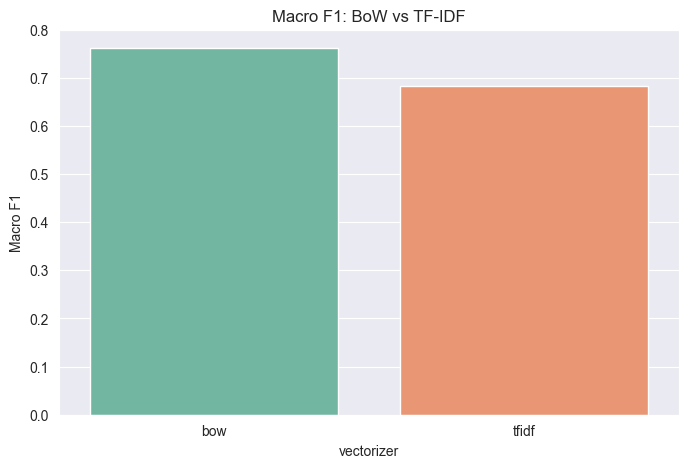

C:\Users\A.RUSSO\AppData\Local\Temp\ipykernel_5520\2222338781.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


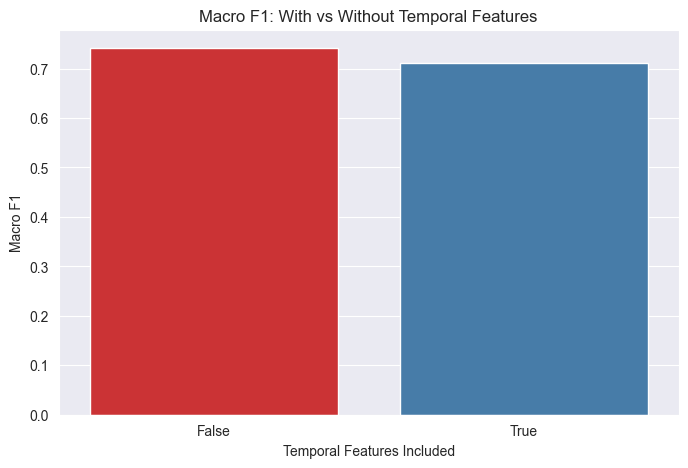

C:\Users\A.RUSSO\AppData\Local\Temp\ipykernel_5520\2222338781.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


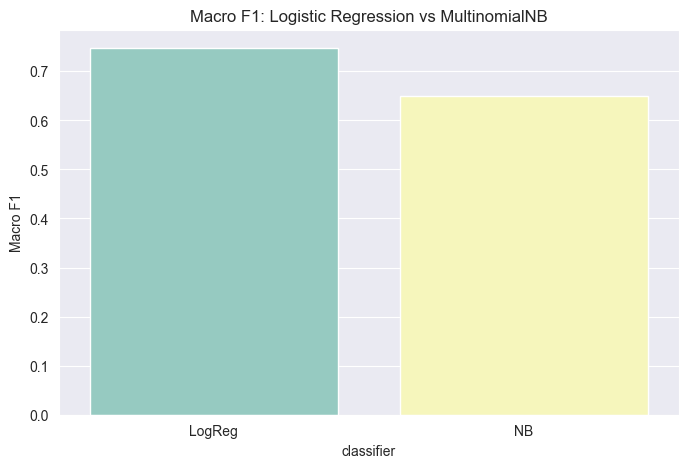

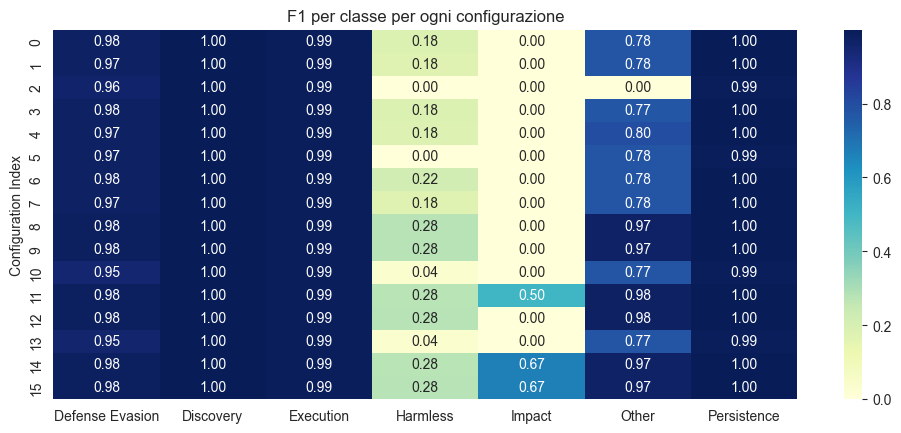

In [7]:
df_stat = run_all_experiments_best(X_train, X_test, y_train, y_test, binary.classes_)

In [36]:
print(df_stat)

                                           model_name classifier vectorizer  \
0   LogReg | tfidf | time=True | scale=True | svd=...     LogReg      tfidf   
1   LogReg | tfidf | time=True | scale=True | svd=100     LogReg      tfidf   
2     NB | tfidf | time=True | scale=False | svd=None         NB      tfidf   
3   LogReg | tfidf | time=True | scale=False | svd...     LogReg      tfidf   
4   LogReg | tfidf | time=True | scale=False | svd...     LogReg      tfidf   
5    NB | tfidf | time=False | scale=False | svd=None         NB      tfidf   
6   LogReg | tfidf | time=False | scale=False | sv...     LogReg      tfidf   
7   LogReg | tfidf | time=False | scale=False | sv...     LogReg      tfidf   
8    LogReg | bow | time=True | scale=True | svd=None     LogReg        bow   
9     LogReg | bow | time=True | scale=True | svd=100     LogReg        bow   
10      NB | bow | time=True | scale=False | svd=None         NB        bow   
11  LogReg | bow | time=True | scale=False | svd=Non

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Migliori iperparametri:
{'clf__estimator__C': 0.1, 'clf__estimator__class_weight': None}

Macro F1 (CV): 0.7725879000482757

===== TEST SET =====
                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       1.00      0.99      0.99     27717
       Harmless       0.92      0.17      0.28       670
         Impact       1.00      0.50      0.67         2
          Other       0.99      0.96      0.98       103
    Persistence       1.00      1.00      1.00     63431

      micro avg       1.00      0.99      1.00    167216
      macro avg       0.99      0.80      0.84    167216
   weighted avg       1.00      0.99      1.00    167216
    samples avg       1.00      0.99      1.00    167216



C:\Users\A.RUSSO\project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



===== TRAIN SET =====


C:\Users\A.RUSSO\project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       1.00      0.99      0.99     65210
       Harmless       0.91      0.17      0.29      1536
         Impact       0.86      0.24      0.38        25
          Other       1.00      0.98      0.99       224
    Persistence       1.00      1.00      1.00    147864

      micro avg       1.00      0.99      1.00    390710
      macro avg       0.97      0.76      0.80    390710
   weighted avg       1.00      0.99      1.00    390710
    samples avg       1.00      0.99      1.00    390710



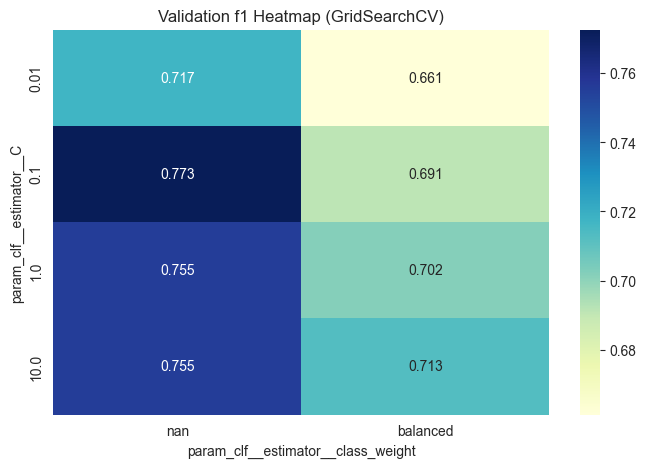

In [ ]:

from sklearn.model_selection import GridSearchCV

preprocess = ColumnTransformer(
    transformers=[
        (
            "text",
            Pipeline([
                ("bow", CountVectorizer(
                    lowercase=True,
                    token_pattern=r"[^\s|;(){}:'\"><]+"
                )),
                ("svd", TruncatedSVD(
                    n_components=100,
                    random_state=42
                ))
            ]),
            "decoded_payload"
        )
    ],
    remainder="drop"
)

logreg = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    )
)



pipeL = Pipeline([
    ("prep", preprocess),
    ("clf", logreg)
])


param_grid = {
    "clf__estimator__C": [0.01, 0.1, 1, 10],

    "clf__estimator__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipeL,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)



print("Best:")
print(grid.best_params_)

print("\nMacro F1 (CV):", grid.best_score_)

best_model = grid.best_estimator_


y_pred_test = best_model.predict(X_test)

print("\n===== TEST SET =====")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=binary.classes_
    )
)


y_pred_train = best_model.predict(X_train)

print("\n===== TRAIN SET =====")
print(
    classification_report(
        y_train,
        y_pred_train,
        target_names=binary.classes_
    )
)

df_gridL = pd.DataFrame(grid.cv_results_)
heatmap_dfL = df_gridL[[
    "param_clf__estimator__C",
    "param_clf__estimator__class_weight",
    "mean_test_score"
]].copy()
heatmap_dfL["param_clf__estimator__C"] = heatmap_dfL["param_clf__estimator__C"].astype(str)
heatmap_data = heatmap_dfL.pivot(
    index="param_clf__estimator__C",
    columns="param_clf__estimator__class_weight",
    values="mean_test_score"
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Validation f1 Heatmap (GridSearchCV)")
plt.ylabel("param_clf__estimator__C")
plt.xlabel("param_clf__estimator__class_weight")
plt.show()


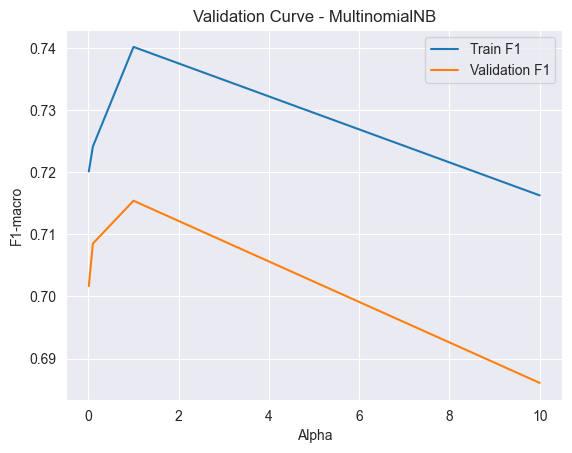

In [38]:
import numpy as np
from sklearn.model_selection import validation_curve



preprocess = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(lowercase=True, token_pattern=r'[^\s|;(){}:\'\"><]+'), "decoded_payload"),
    ],
    remainder="drop"
)



multi = OneVsRestClassifier(
    MultinomialNB(
    )
)



pipeN = Pipeline([
    ("prep", preprocess),
    ("clf", multi)
])



param_range = [0.01, 0.1, 1, 10]
train_scores, test_scores = validation_curve(
    pipeN,
    X_train,
    y_train,
    param_name="clf__estimator__alpha",
    param_range=param_range,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


plt.plot(param_range, train_mean, label="Train F1")
plt.plot(param_range, test_mean, label="Validation F1")
plt.xlabel("Alpha")
plt.ylabel("F1-macro")
plt.title("Validation Curve - MultinomialNB")
plt.legend()
plt.show()


Default F1: 0.841677426614873
Best Model F1: 0.8420507871723627
Miglioramento percentuale: 0.04%


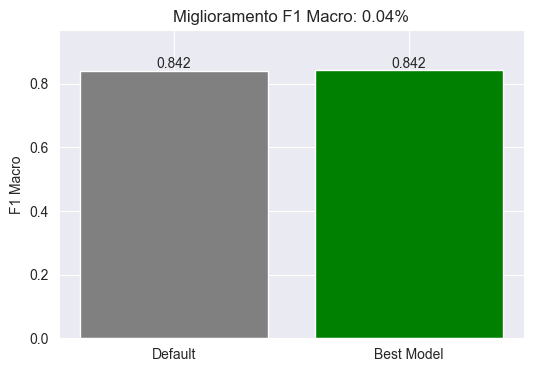

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score



pipeL.fit(X_train, y_train)
y_pred_default = pipeL.predict(X_test)
default_f1 = f1_score(y_test, y_pred_default, average="macro")

print("Default F1:", default_f1)




y_pred_best = best_model.predict(X_test)
best_f1 = f1_score(y_test, y_pred_best, average="macro")

print("Best Model F1:", best_f1)




improvement = (best_f1 - default_f1) / default_f1 * 100
print(f"Miglioramento percentuale: {improvement:.2f}%")



labels = ["Default", "Best Model"]
scores = [default_f1, best_f1]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, scores, color=["gray", "green"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.title(f"Improved F1 Macro: {improvement:.2f}%")
plt.ylabel("F1 Macro")
plt.ylim(0, max(scores) * 1.15)
plt.show()


C:\Users\A.RUSSO\project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A.RUSSO\project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       1.00      0.99      0.99     27717
       Harmless       0.92      0.17      0.28       670
         Impact       1.00      0.50      0.67         2
          Other       0.98      0.96      0.97       103
    Persistence       1.00      1.00      1.00     63431

      micro avg       1.00      0.99      1.00    167216
      macro avg       0.98      0.80      0.84    167216
   weighted avg       1.00      0.99      1.00    167216
    samples avg       1.00      0.99      1.00    167216



C:\Users\A.RUSSO\project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


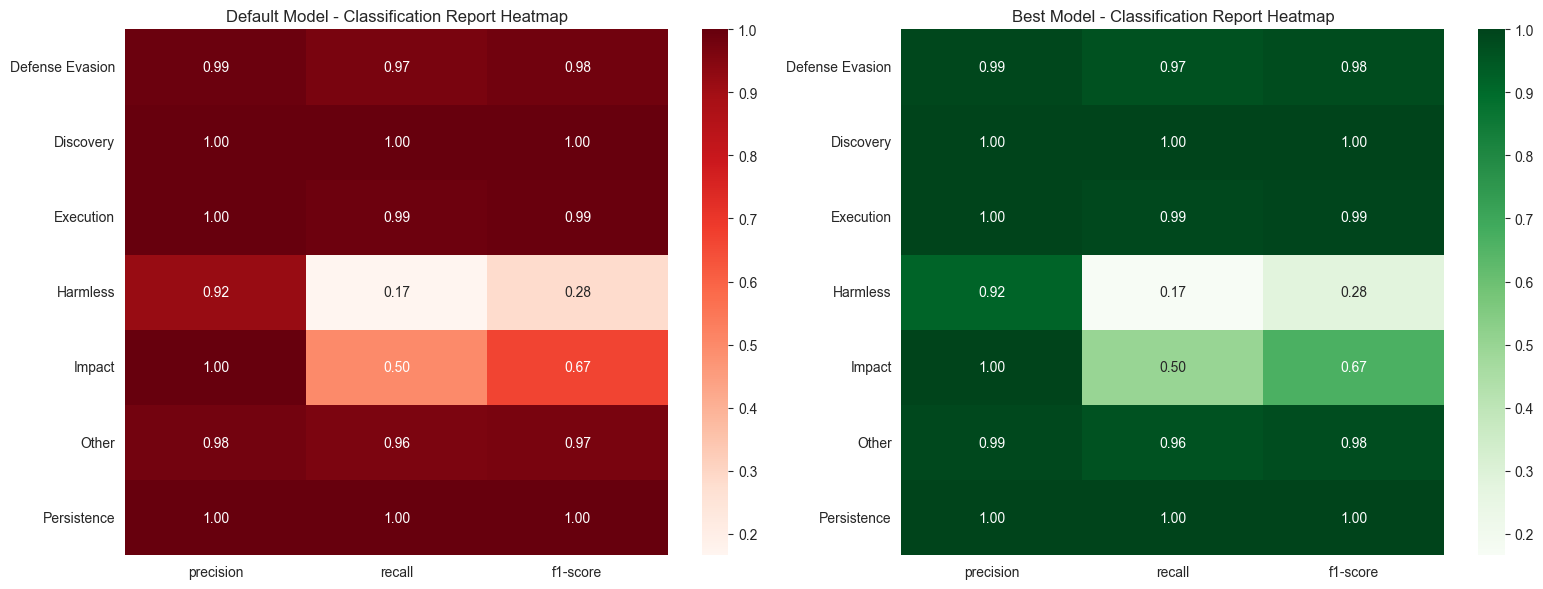

In [ ]:



report_default = classification_report(
    y_test, y_pred_default, target_names=binary.classes_, output_dict=True
)
print(classification_report(
    y_test, y_pred_default, target_names=binary.classes_))

report_best = classification_report(
    y_test, y_pred_best, target_names=binary.classes_, output_dict=True
)



df_default = pd.DataFrame(report_default).transpose()
df_best = pd.DataFrame(report_best).transpose()

metrics = ["precision", "recall", "f1-score"]

df_default = df_default.loc[binary.classes_, metrics]
df_best = df_best.loc[binary.classes_, metrics]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_default, annot=True, cmap="Reds", fmt=".2f", ax=axes[0])
axes[0].set_title("Default Model - Classification Report Heatmap")

sns.heatmap(df_best, annot=True, cmap="Greens", fmt=".2f", ax=axes[1])
axes[1].set_title("Best Model - Classification Report Heatmap")

plt.tight_layout()
plt.show()
